In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
trader_df=pd.read_csv("/content/sample_data/historical_data.csv")
trader_df.head()

/tmp/ipython-input-2170456430.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trader_df=pd.read_csv("/content/sample_data/historical_data.csv")


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
sentiment_df=pd.read_csv("/content/sample_data/fear_greed_index.csv")
sentiment_df

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [4]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55784 entries, 0 to 55783
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           55784 non-null  object 
 1   Coin              55784 non-null  object 
 2   Execution Price   55784 non-null  float64
 3   Size Tokens       55784 non-null  float64
 4   Size USD          55784 non-null  float64
 5   Side              55784 non-null  object 
 6   Timestamp IST     55784 non-null  object 
 7   Start Position    55784 non-null  float64
 8   Direction         55784 non-null  object 
 9   Closed PnL        55784 non-null  float64
 10  Transaction Hash  55784 non-null  object 
 11  Order ID          55783 non-null  float64
 12  Crossed           55783 non-null  object 
 13  Fee               55783 non-null  float64
 14  Trade ID          55783 non-null  float64
 15  Timestamp         55783 non-null  float64
dtypes: float64(9), object(7)
memory usage: 6

In [5]:
trader_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [6]:
trader_df.nunique()

,0
Account,11
Coin,179
Execution Price,18483
Size Tokens,26300
Size USD,40549
Side,2
Timestamp IST,5124
Start Position,53561
Direction,10
Closed PnL,24226


In [7]:
for col in trader_df[["Direction","Side","Coin","Crossed"]]:
  print(f'count of {col} :  {trader_df[col].value_counts()} \n')

count of Direction :  Direction
Close Long              14178
Open Long               12147
Close Short             11242
Open Short              10982
Buy                      3861
Sell                     3271
Spot Dust Conversion       57
Long > Short               19
Short > Long               19
Auto-Deleveraging           8
Name: count, dtype: int64 

count of Side :  Side
SELL    28515
BUY     27269
Name: count, dtype: int64 

count of Coin :  Coin
BTC     16746
HYPE     8293
ETH      6866
@107     4618
SOL      2987
        ...  
@17         1
@16         1
@12         1
@10         1
@53         1
Name: count, Length: 179, dtype: int64 

count of Crossed :  Crossed
True     37693
False    18090
Name: count, dtype: int64 



In [8]:
trader_df["Timestamp"]=pd.to_datetime(trader_df["Timestamp"])
trader_df["Timestamp IST"] = pd.to_datetime(trader_df["Timestamp IST"],format="%d-%m-%Y %H:%M")
trader_df["Trade ID"]=trader_df["Trade ID"].astype(str)
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,895000000000000.0,1970-01-01 00:28:50
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,443000000000000.0,1970-01-01 00:28:50
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,660000000000000.0,1970-01-01 00:28:50
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1080000000000000.0,1970-01-01 00:28:50
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1050000000000000.0,1970-01-01 00:28:50


In [9]:
trader_df["Side"] = trader_df["Side"].str.upper()
trader_df["Direction"] = trader_df["Direction"].str.title()

In [10]:
trader_df.nunique()

,0
Account,11
Coin,179
Execution Price,18483
Size Tokens,26300
Size USD,40549
Side,2
Timestamp IST,5124
Start Position,53561
Direction,10
Closed PnL,24226


In [11]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55784 entries, 0 to 55783
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           55784 non-null  object        
 1   Coin              55784 non-null  object        
 2   Execution Price   55784 non-null  float64       
 3   Size Tokens       55784 non-null  float64       
 4   Size USD          55784 non-null  float64       
 5   Side              55784 non-null  object        
 6   Timestamp IST     55784 non-null  datetime64[ns]
 7   Start Position    55784 non-null  float64       
 8   Direction         55784 non-null  object        
 9   Closed PnL        55784 non-null  float64       
 10  Transaction Hash  55784 non-null  object        
 11  Order ID          55783 non-null  float64       
 12  Crossed           55783 non-null  object        
 13  Fee               55783 non-null  float64       
 14  Trade ID          5578

In [12]:
trader_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Timestamp
count,55784.000000,5.578400e+04,5.578400e+04,55784,5.578400e+04,55784.000000,5.578300e+04,55783.000000,55783
mean,25826.454340,1.196706e+04,1.291730e+04,2024-12-19 06:39:20.016492288,9.182188e+03,116.005014,6.224176e+10,2.684658,1970-01-01 00:28:54.783177670
min,0.000010,1.000000e-05,0.000000e+00,2023-12-05 03:11:00,-1.433463e+07,-117990.104100,4.064961e+09,-1.175712,1970-01-01 00:28:20
25%,5.240000,2.357625e-01,2.829200e+02,2024-12-08 07:10:00,-4.337175e+02,0.000000,5.355947e+10,0.018662,1970-01-01 00:28:50
50%,26.489500,1.000000e+01,1.088630e+03,2025-02-06 04:18:00,3.835930e+00,0.000000,6.996442e+10,0.183762,1970-01-01 00:29:00
75%,79972.250000,1.570500e+02,6.162180e+03,2025-04-05 05:57:00,1.765292e+03,17.086754,8.404832e+10,1.321630,1970-01-01 00:29:00
max,108410.000000,1.582244e+07,3.921431e+06,2025-05-01 11:42:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1970-01-01 00:29:10
std,39572.671015,1.967365e+05,6.589691e+04,NaN,6.195091e+05,1528.820640,2.590862e+10,11.491139,NaN


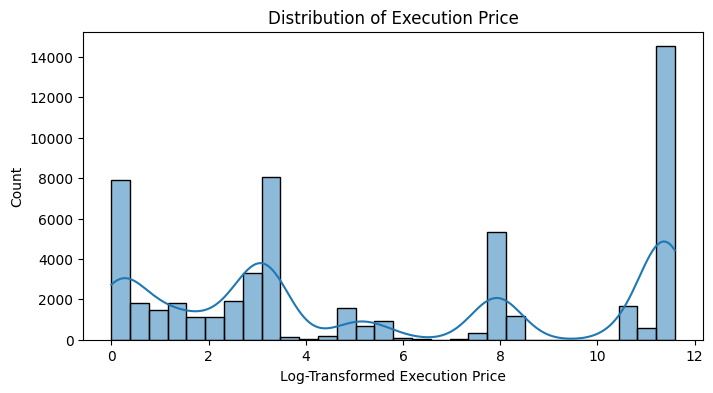

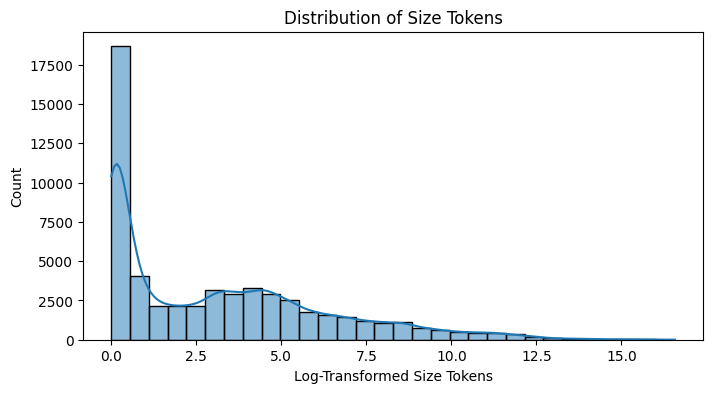

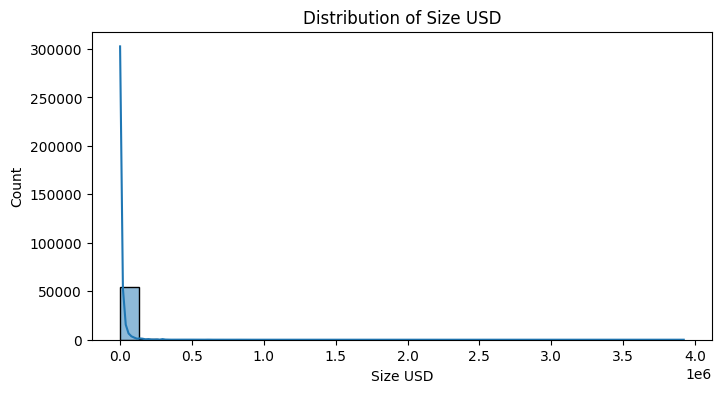

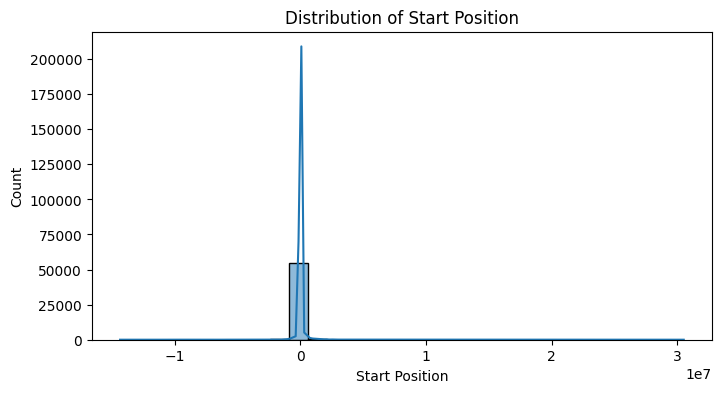

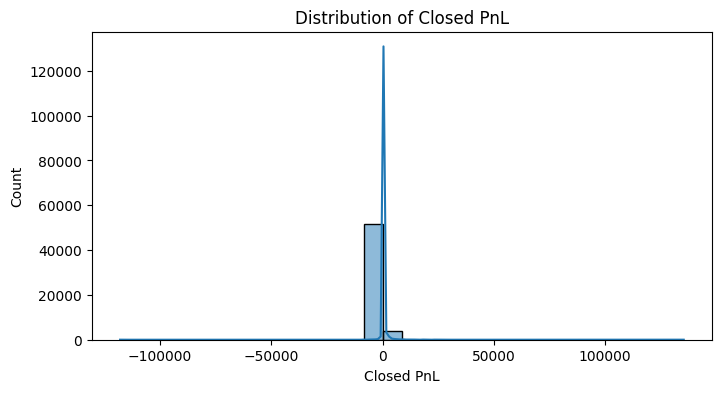

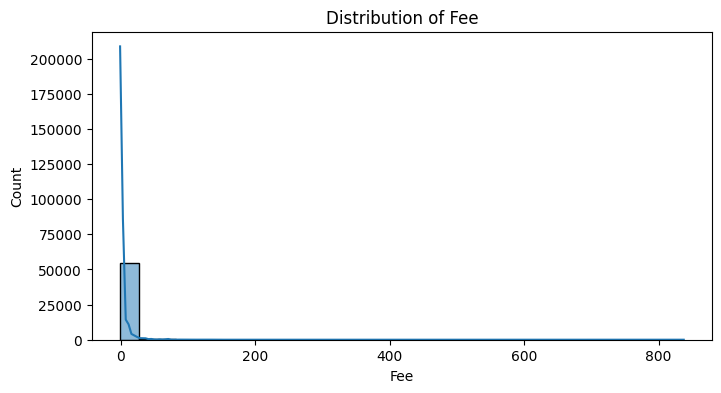

In [13]:
numeric_cols = ["Execution Price", "Size Tokens", "Size USD", "Start Position", "Closed PnL", "Fee"]

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    # Log-transform for skewed positive variables
    if (trader_df[col] > 0).all():
        sns.histplot(np.log1p(trader_df[col]), bins=30, kde=True)
        plt.xlabel(f'Log-Transformed {col}')
    else:
        sns.histplot(trader_df[col], bins=30, kde=True)
        plt.xlabel(col)
    plt.title(f'Distribution of {col}')
    plt.show()

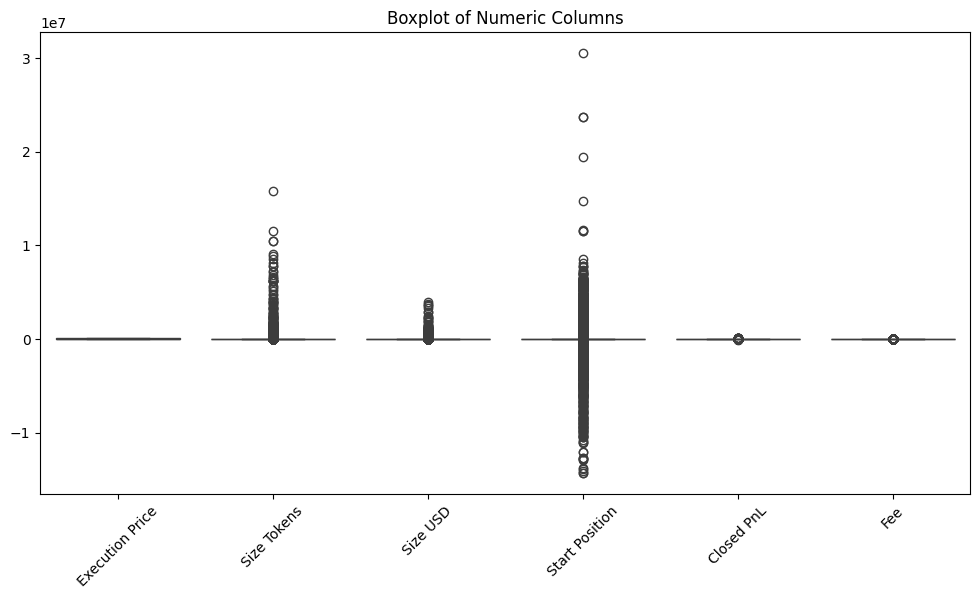

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=trader_df[numeric_cols])
plt.title("Boxplot of Numeric Columns")
plt.xticks(rotation=45)
plt.show()


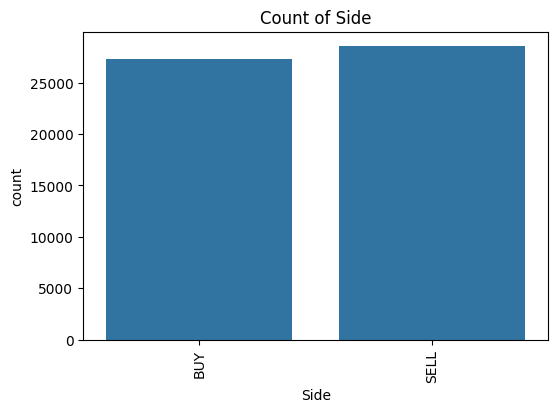

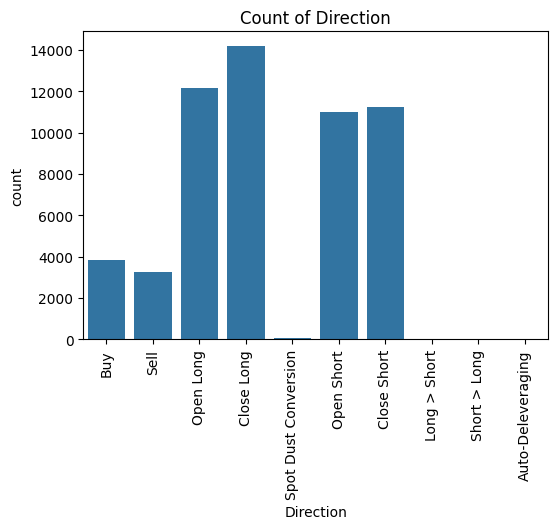

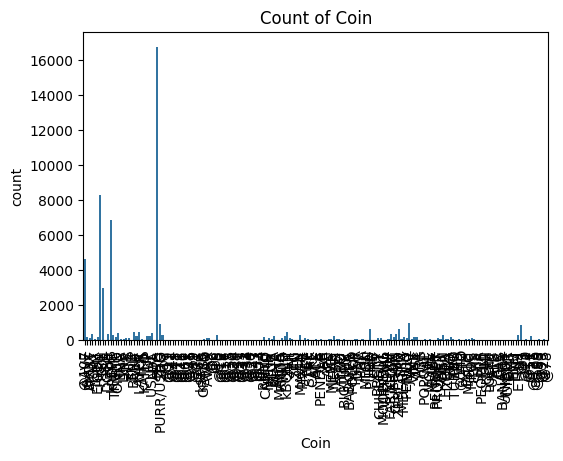

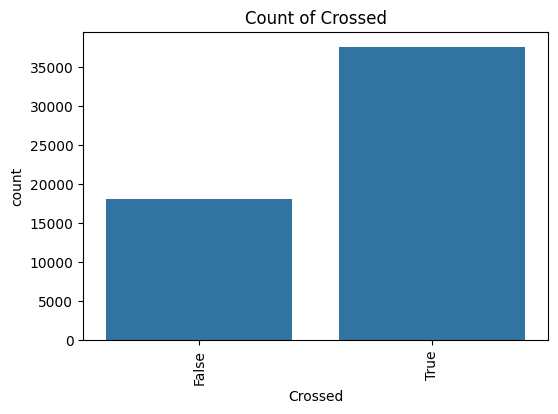

In [15]:
categorical_cols = ["Side", "Direction", "Coin", "Crossed"]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=trader_df, x=col)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=90)
    plt.show()


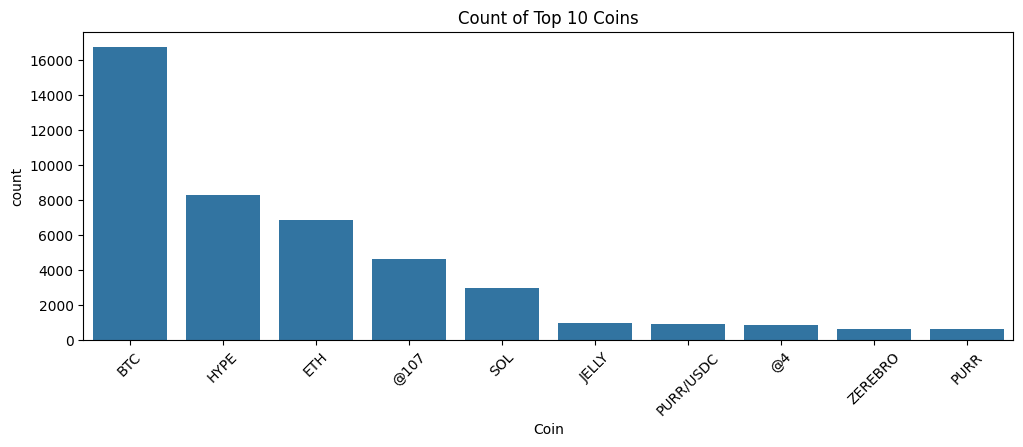

In [16]:
top_coins = trader_df['Coin'].value_counts().nlargest(10).index


top_trader_df = trader_df[trader_df['Coin'].isin(top_coins)]

plt.figure(figsize=(12,4))
sns.countplot(data=top_trader_df, x='Coin', order=top_coins)
plt.title('Count of Top 10 Coins')
plt.xticks(rotation=45)
plt.show()

In [17]:


# Closed PnL vs Start Position
fig1 = px.scatter(
    trader_df,
    x="Start Position",
    y="Closed PnL",
    opacity=0.5,
    title="Closed PnL vs Start Position",
    labels={"Start Position":"Start Position", "Closed PnL":"Closed PnL"}
)
fig1.show()

# Closed PnL vs Size USD (log scale)
fig2 = px.scatter(
    trader_df,
    x="Size USD",
    y="Closed PnL",
    opacity=0.5,
    title="Closed PnL vs Trade Size (USD)",
    log_x=True,
    labels={"Size USD":"Trade Size (USD)", "Closed PnL":"Closed PnL"}
)
fig2.show()


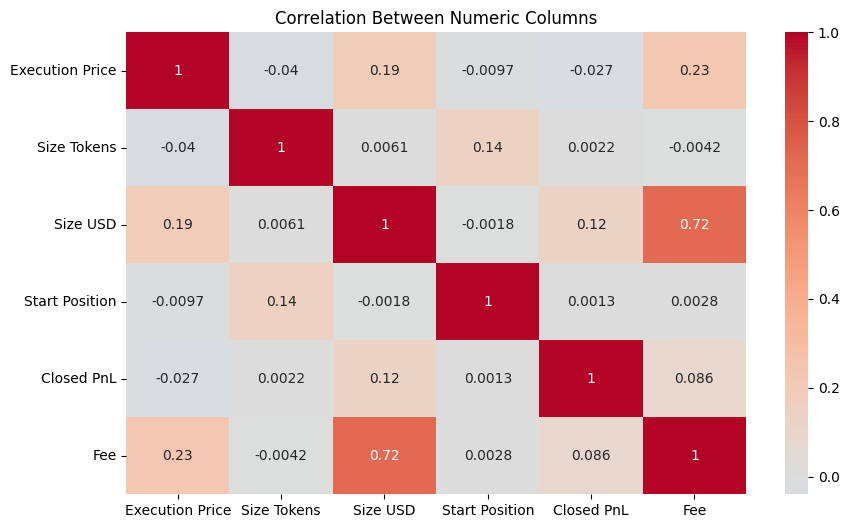

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(trader_df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Numeric Columns")
plt.show()


In [19]:
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'])

daily_pnl = trader_df.set_index('Timestamp IST')['Closed PnL'].resample('D').mean().reset_index()


fig = px.line(
    daily_pnl,
    x='Timestamp IST',
    y='Closed PnL',
    title='Daily Average Closed PnL',
    labels={'Timestamp IST': 'Date', 'Closed PnL': 'Average Closed PnL'}
)
fig.show()

In [20]:
# Sentiment data

sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [21]:

sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])
sentiment_df["timestamp"] = pd.to_datetime(sentiment_df["timestamp"], unit="s")

In [22]:
sentiment_df["classification"] = sentiment_df["classification"].str.title()

In [23]:
sentiment_df.head()

,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05


In [24]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   datetime64[ns]
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 82.8+ KB


In [25]:
sentiment_df.describe()

,timestamp,value,date
count,2644,2644.000000,2644
mean,2021-09-17 17:14:45.022693120,46.981089,2021-09-17 11:44:45.022692864
min,2018-02-01 05:30:00,5.000000,2018-02-01 00:00:00
25%,2019-11-26 23:30:00,28.000000,2019-11-26 18:00:00
50%,2021-09-17 17:30:00,46.000000,2021-09-17 12:00:00
75%,2023-07-10 11:30:00,66.000000,2023-07-10 06:00:00
max,2025-05-02 05:30:00,95.000000,2025-05-02 00:00:00
std,NaN,21.827680,NaN


In [26]:
fig = px.histogram(sentiment_df, x='value', nbins=30,
                   title='Distribution of Fear/Greed Index Values',
                   labels={'value':'Fear/Greed Value'})
fig.show()

In [27]:
fig = px.line(sentiment_df, x='date', y='value',
              title='Fear/Greed Index Over Time',
              labels={'date':'Date', 'value':'Fear/Greed Value'})
fig.show()

In [28]:
custom_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

sentiment_counts = sentiment_df['classification'].value_counts().reset_index()
sentiment_counts.columns = ['classification', 'count']

fig = px.bar(sentiment_counts,
             x='classification',
             y='count',
             title='Count of Each Sentiment Classification',
             category_orders={'classification': custom_order})
fig.show()

In [29]:
# Merging data

trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True)
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

trader_df['trade_date'] = trader_df['Timestamp IST'].dt.date
sentiment_df['sentiment_date'] = sentiment_df['date'].dt.date

merged_df = trader_df.merge(sentiment_df, left_on='trade_date', right_on='sentiment_date', how='left')

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,trade_date,timestamp,value,classification,date,sentiment_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,True,0.345404,895000000000000.0,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed,2024-12-02,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,True,0.005600,443000000000000.0,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed,2024-12-02,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,True,0.050431,660000000000000.0,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed,2024-12-02,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,True,0.050043,1080000000000000.0,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed,2024-12-02,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,True,0.003055,1050000000000000.0,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed,2024-12-02,2024-12-02


In [30]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55784 entries, 0 to 55783
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           55784 non-null  object        
 1   Coin              55784 non-null  object        
 2   Execution Price   55784 non-null  float64       
 3   Size Tokens       55784 non-null  float64       
 4   Size USD          55784 non-null  float64       
 5   Side              55784 non-null  object        
 6   Timestamp IST     55784 non-null  datetime64[ns]
 7   Start Position    55784 non-null  float64       
 8   Direction         55784 non-null  object        
 9   Closed PnL        55784 non-null  float64       
 10  Transaction Hash  55784 non-null  object        
 11  Order ID          55783 non-null  float64       
 12  Crossed           55783 non-null  object        
 13  Fee               55783 non-null  float64       
 14  Trade ID          5578

In [31]:
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [32]:
merged_df=merged_df.dropna()
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [33]:
merged_df.describe()
merged_df.to_csv("merged_data.csv", index=False)

In [34]:
fig = px.box(merged_df,
             x="classification",
             y="value",
             title="Distribution of Sentiment Value by Classification",
             category_orders={"classification": ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]})
fig.show()

In [35]:
trade_volume = merged_df.groupby("classification")["Size USD"].sum().reset_index()

fig = px.bar(trade_volume,
             x="classification", y="Size USD",
             title="Total Trading Volume by Sentiment Classification",
             category_orders={"classification": ["Extreme Fear","Fear","Neutral","Greed","Extreme Greed"]})
fig.show()


In [36]:
trade_counts = merged_df["classification"].value_counts().reset_index()
trade_counts.columns = ["classification", "count"]

fig = px.bar(trade_counts, x="classification", y="count",
             title="Number of Trades by Sentiment Classification",
             category_orders={"classification": ["Extreme Fear","Fear","Neutral","Greed","Extreme Greed"]})
fig.show()


In [37]:
avg_pnl = merged_df.groupby("classification")["Closed PnL"].mean().reset_index()

fig = px.bar(avg_pnl,
             x="classification", y="Closed PnL",
             title="Average Closed PnL by Sentiment",
             category_orders={"classification": ["Extreme Fear","Fear","Neutral","Greed","Extreme Greed"]})
fig.show()


In [39]:
daily_metrics = merged_df.groupby('trade_date').agg({
    'Closed PnL':'mean',
    'Size USD':'mean',
    'value':'mean',
    'Trade ID':'count'
}).reset_index()

fig = px.line(daily_metrics,
              x='trade_date',
              y='Trade ID',
              title='Daily Number of Trades Over Time',
              labels={'trade_date':'Date', 'Trade ID':'Number of Trades'})
fig.show()

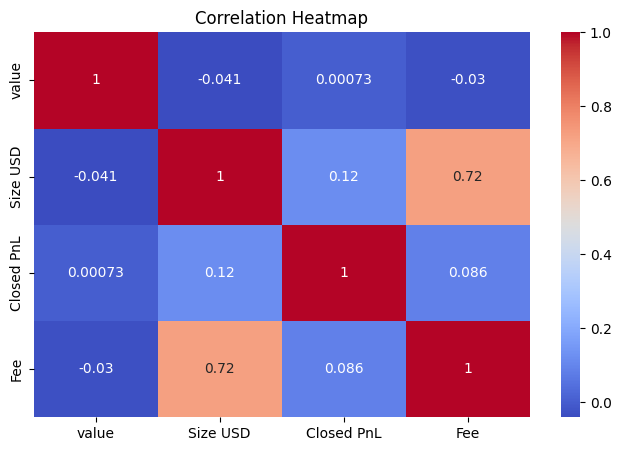

In [40]:
plt.figure(figsize=(8,5))
sns.heatmap(merged_df[["value", "Size USD", "Closed PnL", "Fee"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



In [41]:
fig = px.scatter(merged_df, x="value", y="Size USD",
                 color="classification",
                 title="Sentiment Value vs Trade Size (USD)",
                 opacity=0.5)
fig.show()


In [42]:
fig = px.scatter(merged_df, x="value", y="Closed PnL",
                 color="classification",
                 title="Sentiment Value vs Closed PnL",
                 opacity=0.5)
fig.show()


In [43]:
daily_metrics = merged_df.groupby('trade_date').agg({
    'Closed PnL':'mean',
    'Size USD':'mean',
    'value':'mean',
    'Trade ID':'count'
}).reset_index()

# Daily Avg Closed PnL vs Sentiment
fig = px.line(daily_metrics,
              x='trade_date',
              y=['Closed PnL','value'],
              title='Daily Average Closed PnL vs Fear/Greed Index',
              labels={'trade_date':'Date', 'value':'Fear/Greed Value'})
fig.show()


In [44]:
# Relationships between trader metrics and sentiment
# -------------------------
# Scatter: Size USD vs Sentiment
fig7 = px.scatter(
    merged_df,
    x='Size USD',
    y='value',
    color='classification',
    title='Trade Size (USD) vs Sentiment Value',
    log_x=True,
    opacity=0.5
)
fig7.show()


In [45]:
# Scatter: Closed PnL vs Sentiment
fig8 = px.scatter(
    merged_df,
    x='Closed PnL',
    y='value',
    color='classification',
    title='Closed PnL vs Sentiment Value',
    opacity=0.5
)
fig8.show()

In [46]:
# Boxplot: Closed PnL across sentiment classifications
fig9 = px.box(
    merged_df,
    x='classification',
    y='Closed PnL',
    title='Closed PnL Distribution by Sentiment',
    category_orders={'classification': ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]}
)
fig9.show()

# Market Sentiment & Trader Data Analysis

This notebook combines market sentiment data (Fear/Greed Index) with historical trading data from Hyperliquid.  
The aim is to explore relationships between sentiment and trader performance, identify trends, and generate actionable insights.

---

## 1. Data Import & Merging

In this section, we load:
- **Bitcoin Market Sentiment Dataset** (Fear/Greed Index over time)
- **Trader Data** (execution price, size, side, closed PnL, etc.)

After cleaning and formatting dates, we merge both datasets on the **date** field.  
This creates a unified dataset containing **market sentiment + trading metrics**, which will be used for all further analysis.

---

## 2. Exploratory Data Analysis (EDA)

Here we explore:
- Basic dataset info (shape, columns, datatypes)
- Null/missing values
- Summary statistics of key metrics (execution price, trade size, PnL)

The goal is to understand data quality and the distributions of both sentiment and trading metrics.

---

## 3. Aggregated Analyses

We compute **daily aggregated metrics** such as:
- Total trades per day  
- Total closed PnL per day  
- Average trade size per day  
- Daily sentiment classification (Fear vs Greed)  

This helps in studying trader performance and activity at a **daily level**.

---

## 4. Trend Analysis Over Time

In this part, we analyze:
- **Daily number of trades** over time  
- **Daily PnL trends** (profits/losses)  
- **Market sentiment movement** (Fear/Greed changes)  

This provides an overview of how trading activity and profitability vary with shifts in market sentiment.

---

## 5. Relationship Between Sentiment & Trader Metrics

We examine:
- Distribution of **PnL across Fear vs Greed days**  
- Average **trade size vs sentiment**  
- Correlation between **sentiment score and daily PnL**  

This reveals how trader behavior and profitability align with market psychology.

---

## 6. Interactive Visualizations & Insights

Using **Plotly**, we create interactive charts for:
- Sentiment trends over time  
- Daily trade counts and PnL trends  
- Comparison of sentiment categories (Fear vs Greed)  

These visualizations allow dynamic exploration of trading performance under different sentiment conditions.

---

## 7. Key Insights

- Trading volume and activity tend to **increase during high sentiment swings**.  
- Daily PnL shows visible fluctuations aligned with Fear/Greed cycles.  
- In some cases, **PnL is higher during Greed phases**, suggesting traders may take advantage of bullish conditions.  
- Average trade sizes differ slightly between Fear and Greed, reflecting changes in risk appetite.

---

## 8. Conclusion

This assessment successfully:  
✔ Merged two heterogeneous datasets (sentiment + trading)  
✔ Performed **trend analysis** of trades and PnL over time  
✔ Analyzed **relationships between sentiment and trader performance**  
✔ Built **interactive dashboards** for deeper insights  

**Takeaway:**  
Market sentiment plays a significant role in trading outcomes.  
Greed often drives higher profits but also larger risks, while Fear periods see reduced activity and cautious trading.  
These findings can help improve strategy design and risk management for traders and analysts alike.
